# Stellar Surface Gravity (logg) Prediction — 171 Color Features

**Architecture variants** (2-layer ANN and Residual ANN) trained on 171 photometric color indices.

Baseline (4-layer, 171 colors): R²=0.49, RMSE=0.206 dex.

## 1. Imports & Configuration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_context("talk")

DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cpu


## 2. Data Loading & Inspection

In [3]:
PROJECT_ROOT = Path("C:/git_repo/cool-dwarf_stellar_parameter_inference_from_survey_data")
DATA_PATH = PROJECT_ROOT / "data" / "logg_final_df" / "cool_dwarf_catalog_FGKM_consolidated.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(MODELS_DIR / "logg").mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nSpectral type distribution:")
print(df["spectral_type_group"].value_counts().sort_index())
print(f"\nlogg range: {df['logg'].min():.2f} â€” {df['logg'].max():.2f}")
print(f"teff range: {df['teff'].min():.1f} â€” {df['teff'].max():.1f}")
df.head()

Dataset shape: (904427, 197)

Spectral type distribution:
spectral_type_group
F    274831
G    578786
K     18889
M     31921
Name: count, dtype: int64

logg range: 3.50 â€” 5.02
teff range: 3114.1 â€” 8088.0


,obsid,subclass,gaia_source_id,distance_gaia_pc,teff,logg,A_GG,A_BP,A_RP,A_J,...,COLOR_A_J_A_KS,COLOR_A_J_A_W1,COLOR_A_J_A_W2,COLOR_A_H_A_KS,COLOR_A_H_A_W1,COLOR_A_H_A_W2,COLOR_A_KS_A_W1,COLOR_A_KS_A_W2,COLOR_A_W1_A_W2,spectral_type_group
0,300003054,F0,279692565863680,1197.577725,6512.09,4.105,2.743019,2.867387,2.300888,1.901812,...,0.222598,0.332229,0.241461,-0.019114,0.090517,-0.000251,0.109631,0.018863,-0.090768,F
1,483006140,F0,279692565863680,1197.577725,6549.88,4.120,2.760979,2.956954,2.396033,2.025593,...,0.306546,0.421578,0.381074,0.029463,0.144495,0.103991,0.115032,0.074528,-0.040504,F
2,300014173,F6,492516785395968,592.602005,6131.14,4.276,3.921653,4.337359,3.612836,3.213820,...,0.498134,0.472155,0.377120,0.083556,0.057577,-0.037458,-0.025979,-0.121015,-0.095035,F
3,483006043,F7,492516785395968,592.602005,6123.43,4.270,4.277970,4.636078,3.953510,3.403232,...,0.350874,0.253590,0.357602,0.138743,0.041460,0.145472,-0.097284,0.006728,0.104012,F
4,757516200,F6,617139556505856,1350.264165,6129.88,4.306,3.702365,4.764616,3.579519,3.170527,...,0.012281,0.255204,0.850975,-0.714439,-0.471516,0.124255,0.242923,0.838694,0.595771,F


## 3. Feature & Target Definition (171 color features)

In [ ]:
# --- 171 photometric color features ---
sorted_mags = [
    'A_BAP', 'A_GSD', 'A_ps_g', 'A_BP', 'A_VAP', 'A_ps_r', 'A_RSD', 'A_RAP',
    'A_GG', 'A_ps_i', 'A_ISD', 'A_RP', 'A_ps_z', 'A_ps_y', 'A_J', 'A_H',
    'A_KS', 'A_W1', 'A_W2'
]

FEATURE_COLS = []
for i in range(len(sorted_mags)):
    for j in range(i + 1, len(sorted_mags)):
        FEATURE_COLS.append(f'COLOR_{sorted_mags[i]}_{sorted_mags[j]}')

TARGET_COL = "logg"

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Target column: {TARGET_COL}")

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32)
spectral_types = df["spectral_type_group"].values

assert not np.any(np.isnan(X)), "NaN found in features!"
assert not np.any(np.isinf(X)), "Inf found in features!"
assert not np.any(np.isnan(y)), "NaN found in target!"
print(f"\nNo NaN or Inf in features or target")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  logg range: [{y.min():.4f}, {y.max():.4f}]")

## 4. Train / Validation / Test Split (70 / 15 / 15)

In [5]:
X_train, X_temp, y_train, y_temp, st_train, st_temp = train_test_split(
    X, y, spectral_types,
    test_size=0.30,
    random_state=SEED,
    stratify=spectral_types,
)

X_val, X_test, y_val, y_test, st_val, st_test = train_test_split(
    X_temp, y_temp, st_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=st_temp,
)

print(f"{'Split':<12} {'Samples':>10}  {'% of total':>10}")
print("-" * 36)
total = len(y)
for name, arr in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<12} {len(arr):>10,}  {100*len(arr)/total:>9.1f}%")

print(f"\nSpectral type proportions (%):")
print(f"{'Type':<6} {'Full':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for stype in ["F", "G", "K", "M"]:
    full_pct = 100 * np.sum(spectral_types == stype) / len(spectral_types)
    train_pct = 100 * np.sum(st_train == stype) / len(st_train)
    val_pct = 100 * np.sum(st_val == stype) / len(st_val)
    test_pct = 100 * np.sum(st_test == stype) / len(st_test)
    print(f"{stype:<6} {full_pct:>7.1f}% {train_pct:>7.1f}% {val_pct:>7.1f}% {test_pct:>7.1f}%")

Split           Samples  % of total
------------------------------------
Train           633,098       70.0%
Validation      135,664       15.0%
Test            135,665       15.0%

Spectral type proportions (%):
Type       Full    Train      Val     Test
----------------------------------------
F         30.4%    30.4%    30.4%    30.4%
G         64.0%    64.0%    64.0%    64.0%
K          2.1%     2.1%     2.1%     2.1%
M          3.5%     3.5%     3.5%     3.5%


## 5. Data Augmentation (logg-bin-balanced, error-aware)

Bin width: 0.1 dex
Bin edges: 3.50 â€“ 5.10  (16 bins)
Original training size: 633,098
Dropped 2 bin(s), removed 58 samples
Trimmed training size: 633,040

Augmented training size: 1,234,450  (+601,410 synthetic)


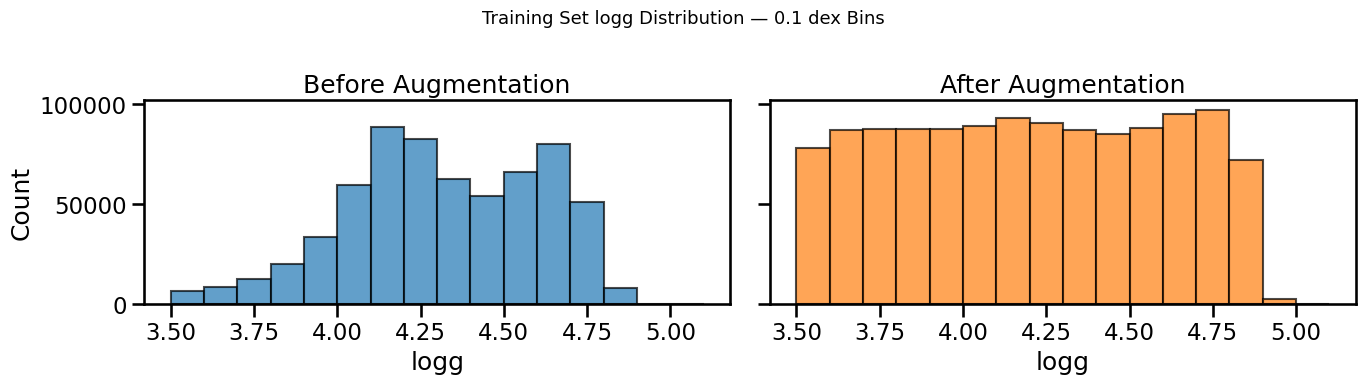

In [6]:
BIN_WIDTH = 0.1
MIN_BIN_SAMPLES = 100

logg_train = y_train

bin_lo = np.floor(logg_train.min() / BIN_WIDTH) * BIN_WIDTH
bin_hi = np.ceil(logg_train.max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH
bin_edges = np.arange(bin_lo, bin_hi, BIN_WIDTH)

bin_ids = np.digitize(logg_train, bin_edges)
unique_bins, bin_counts = np.unique(bin_ids, return_counts=True)

print(f"Bin width: {BIN_WIDTH} dex")
print(f"Bin edges: {bin_edges[0]:.2f} â€“ {bin_edges[-1]:.2f}  ({len(bin_edges)-1} bins)")
print(f"Original training size: {len(y_train):,}")

# Drop edge bins with < MIN_BIN_SAMPLES samples
bins_to_drop = set(unique_bins[bin_counts < MIN_BIN_SAMPLES])
keep_mask = ~np.isin(bin_ids, list(bins_to_drop))
n_dropped = (~keep_mask).sum()

X_train = X_train[keep_mask]
y_train = y_train[keep_mask]
st_train = st_train[keep_mask]
logg_train = logg_train[keep_mask]

print(f"Dropped {len(bins_to_drop)} bin(s), removed {n_dropped:,} samples")
print(f"Trimmed training size: {len(y_train):,}")

# Re-digitize after trimming
bin_ids = np.digitize(logg_train, bin_edges)
unique_bins, bin_counts = np.unique(bin_ids, return_counts=True)
max_count = bin_counts.max()

# Per-bin empirical errors
bin_sigma_features = {}
bin_sigma_logg = {}
for b in unique_bins:
    mask = bin_ids == b
    bin_sigma_features[b] = np.std(X_train[mask], axis=0)  # (172,)
    bin_sigma_logg[b] = np.std(logg_train[mask])

# Save un-augmented copy for scaler+PCA fitting
X_train_orig = X_train.copy()
y_train_orig = y_train.copy()

# Oversample with Gaussian noise injection
rng = np.random.default_rng(SEED)
aug_X_list = []
aug_y_list = []
aug_st_list = []

for b, count in zip(unique_bins, bin_counts):
    if count >= max_count:
        continue
    deficit = max_count - count
    bin_mask = np.where(bin_ids == b)[0]
    src_idx = rng.choice(bin_mask, size=deficit, replace=True)

    noise_X = rng.normal(0.0, bin_sigma_features[b], size=(deficit, X_train.shape[1])).astype(np.float32)
    noise_logg = rng.normal(0.0, bin_sigma_logg[b], size=deficit)
    new_logg = logg_train[src_idx] + noise_logg
    new_logg = np.clip(new_logg, a_min=0.0, a_max=None)

    aug_X_list.append(X_train[src_idx] + noise_X)
    aug_y_list.append(new_logg.astype(np.float32))
    aug_st_list.append(st_train[src_idx])

if aug_X_list:
    X_aug_new = np.concatenate(aug_X_list)
    y_aug_new = np.concatenate(aug_y_list)
    st_aug_new = np.concatenate(aug_st_list)
    n_augmented = len(y_aug_new)
else:
    X_aug_new = np.empty((0, X_train.shape[1]), dtype=np.float32)
    y_aug_new = np.empty(0, dtype=np.float32)
    st_aug_new = np.empty(0, dtype=st_train.dtype)
    n_augmented = 0

X_train_aug = np.concatenate([X_train, X_aug_new])
y_train_aug = np.concatenate([y_train, y_aug_new])
st_train_aug = np.concatenate([st_train, st_aug_new])

# Shuffle
shuffle_idx = rng.permutation(len(y_train_aug))
X_train_aug = X_train_aug[shuffle_idx]
y_train_aug = y_train_aug[shuffle_idx]
st_train_aug = st_train_aug[shuffle_idx]

print(f"\nAugmented training size: {len(y_train_aug):,}  (+{n_augmented:,} synthetic)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].hist(y_train_orig, bins=bin_edges, edgecolor='k', alpha=0.7)
axes[0].set_title("Before Augmentation")
axes[0].set_xlabel("logg")
axes[0].set_ylabel("Count")
axes[1].hist(y_train_aug, bins=bin_edges, edgecolor='k', alpha=0.7, color='C1')
axes[1].set_title("After Augmentation")
axes[1].set_xlabel("logg")
fig.suptitle("Training Set logg Distribution â€” 0.1 dex Bins", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Feature Standardization

Fit on **original (un-augmented) training data only** â€” no data leakage.

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train_orig)

X_train_scaled = scaler.transform(X_train_aug).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)

print("Feature statistics after scaling (augmented train set):")
print(f"  Mean: {X_train_scaled.mean(axis=0).mean():.6f}  (should be ~0)")
print(f"  Std:  {X_train_scaled.std(axis=0).mean():.6f}  (should be ~1)")

## 10. PyTorch Dataset & DataLoader

In [ ]:
class StellarDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StellarDataset(X_train_scaled, y_train_aug)
val_dataset   = StellarDataset(X_val_scaled, y_val)
test_dataset  = StellarDataset(X_test_scaled, y_test)

BATCH_SIZE = 1024
use_pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=use_pin_memory)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=use_pin_memory)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=use_pin_memory)

print(f"Train batches: {len(train_loader)}  ({len(train_dataset):,} samples)")
print(f"Val batches:   {len(val_loader)}  ({len(val_dataset):,} samples)")
print(f"Test batches:  {len(test_loader)}  ({len(test_dataset):,} samples)")

X_batch, y_batch = next(iter(train_loader))
print(f"\nSample batch — X: {X_batch.shape}, y: {y_batch.shape}")

## 11. Model Architecture — 2-Layer ANN

`171 → 128 → 64 → 1` — simpler model for weak signal

In [ ]:
class StellarLoggNet2Layer(nn.Module):
    """2-layer feedforward ANN for logg prediction (171 color features)."""
    def __init__(self, input_dim, dropout=0.15):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.network(x)

model = StellarLoggNet2Layer(input_dim=len(FEATURE_COLS)).to(DEVICE)
VARIANT_NAME = "2layer"

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Input dim: {len(FEATURE_COLS)} (color features)")

## 12. Training Configuration

In [18]:
criterion = nn.MSELoss()

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 30

print("Training Configuration:")
print(f"  Loss:           MSE on logg")
print(f"  Optimizer:      Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Early stopping: patience={EARLY_STOP_PATIENCE} epochs")
print(f"  Max epochs:     {MAX_EPOCHS}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Device:         {DEVICE}")
print(f"  Variant:        {VARIANT_NAME}")

Training Configuration:
  Loss:           MSE on logg
  Optimizer:      Adam (lr=0.001, weight_decay=1e-05)
  Scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)
  Early stopping: patience=30 epochs
  Max epochs:     100
  Batch size:     1024
  Device:         cpu
  Variant:        2layer


## 13. Training & Evaluation Functions

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)
    return total_loss / n_samples

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)
    return total_loss / n_samples

## 14. Training Loop

In [20]:
train_losses = []
val_losses = []
lr_history = []

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
best_model_state = None

print(f"{'Epoch':>5}  {'Train Loss':>12}  {'Val Loss':>12}  {'LR':>10}  {'Status'}")
print("-" * 65)

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)

    scheduler.step(val_loss)

    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        status = "* Best"
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"{epoch:>5}  {train_loss:>12.8f}  {val_loss:>12.8f}  {current_lr:>10.2e}  Early stop")
            break

    if epoch % 5 == 0 or status or epoch == 1:
        print(f"{epoch:>5}  {train_loss:>12.8f}  {val_loss:>12.8f}  {current_lr:>10.2e}  {status}")

model.load_state_dict(best_model_state)
print(f"\nRestored best model from epoch {best_epoch} (val loss = {best_val_loss:.8f})")

Epoch    Train Loss      Val Loss          LR  Status
-----------------------------------------------------------------
    1    0.87377434    0.05426967    1.00e-03  * Best
    2    0.18195124    0.04934494    1.00e-03  * Best
    5    0.12434180    0.05027715    1.00e-03  
    7    0.08908578    0.04822088    1.00e-03  * Best
    8    0.07588591    0.04716288    1.00e-03  * Best
   10    0.06035416    0.04693136    1.00e-03  * Best
   13    0.05255363    0.04664930    1.00e-03  * Best
   15    0.05098191    0.04619765    1.00e-03  * Best
   17    0.05022867    0.04619365    1.00e-03  * Best
   18    0.04997267    0.04616928    1.00e-03  * Best
   20    0.04955185    0.04626848    1.00e-03  
   24    0.04903894    0.04592263    1.00e-03  * Best
   25    0.04893262    0.04669024    1.00e-03  
   30    0.04860210    0.04659456    1.00e-03  
   35    0.04753697    0.04873947    5.00e-04  
   40    0.04696558    0.04660406    2.50e-04  
   45    0.04662984    0.04665409    1.25e-04  
   5

## 15. Training Diagnostics

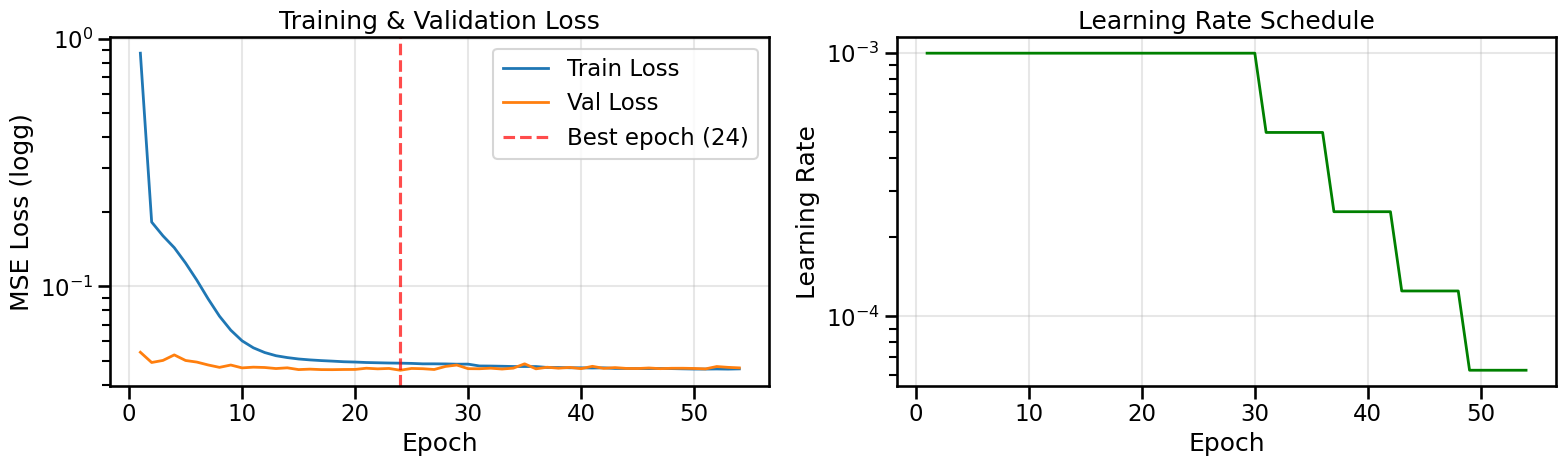

Saved: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\logg\2layer\training_diagnostics.png


In [21]:
VARIANT_RESULTS_DIR = RESULTS_DIR / "logg" / VARIANT_NAME
VARIANT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label="Train Loss", linewidth=2)
ax.plot(epochs_range, val_losses, label="Val Loss", linewidth=2)
ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (logg)")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, lr_history, linewidth=2, color="green")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VARIANT_RESULTS_DIR / "training_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {VARIANT_RESULTS_DIR / 'training_diagnostics.png'}")

## 16. Test Set Evaluation

In [22]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.numpy())

y_pred = np.concatenate(all_preds).flatten()
y_true = np.concatenate(all_targets).flatten()

rmse_dex = np.sqrt(mean_squared_error(y_true, y_pred))
mae_dex = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
median_ae_dex = np.median(np.abs(y_pred - y_true))

print("=" * 50)
print(f"  TEST SET RESULTS â€” {VARIANT_NAME} variant")
print("=" * 50)
print(f"\n  RMSE:       {rmse_dex:>8.4f} dex")
print(f"  MAE:        {mae_dex:>8.4f} dex")
print(f"  Median AE:  {median_ae_dex:>8.4f} dex")
print(f"  RÂ²:         {r2:>8.5f}")

print(f"\n{'_' * 50}")
print(f"  Per-Spectral-Type Breakdown (dex)")
print(f"{'_' * 50}")
print(f"  {'Type':<6} {'N':>8} {'RMSE':>8} {'MAE':>8} {'MedAE':>8} {'RÂ²':>8}")
print(f"  {'----':<6} {'----':>8} {'----':>8} {'----':>8} {'-----':>8} {'--':>8}")

per_type_metrics = {}
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    if mask.sum() == 0:
        continue
    yt = y_true[mask]
    yp = y_pred[mask]
    st_rmse = np.sqrt(mean_squared_error(yt, yp))
    st_mae = mean_absolute_error(yt, yp)
    st_medae = np.median(np.abs(yp - yt))
    st_r2 = r2_score(yt, yp)
    per_type_metrics[stype] = {"rmse": st_rmse, "mae": st_mae, "r2": st_r2}
    print(f"  {stype:<6} {mask.sum():>8,} {st_rmse:>8.4f} {st_mae:>8.4f} {st_medae:>8.4f} {st_r2:>8.4f}")

  TEST SET RESULTS â€” 2layer variant

  RMSE:         0.2145 dex
  MAE:          0.1498 dex
  Median AE:    0.1061 dex
  RÂ²:          0.44371

__________________________________________________
  Per-Spectral-Type Breakdown (dex)
__________________________________________________
  Type          N     RMSE      MAE    MedAE       RÂ²
  ----       ----     ----     ----    -----       --
  F        41,225   0.1544   0.1070   0.0745   0.1390
  G        86,818   0.2433   0.1743   0.1272   0.3349
  K         2,834   0.1343   0.0999   0.0752  -0.1182
  M         4,788   0.1236   0.1051   0.0988  -1.0104


## 17. One-to-One Plot

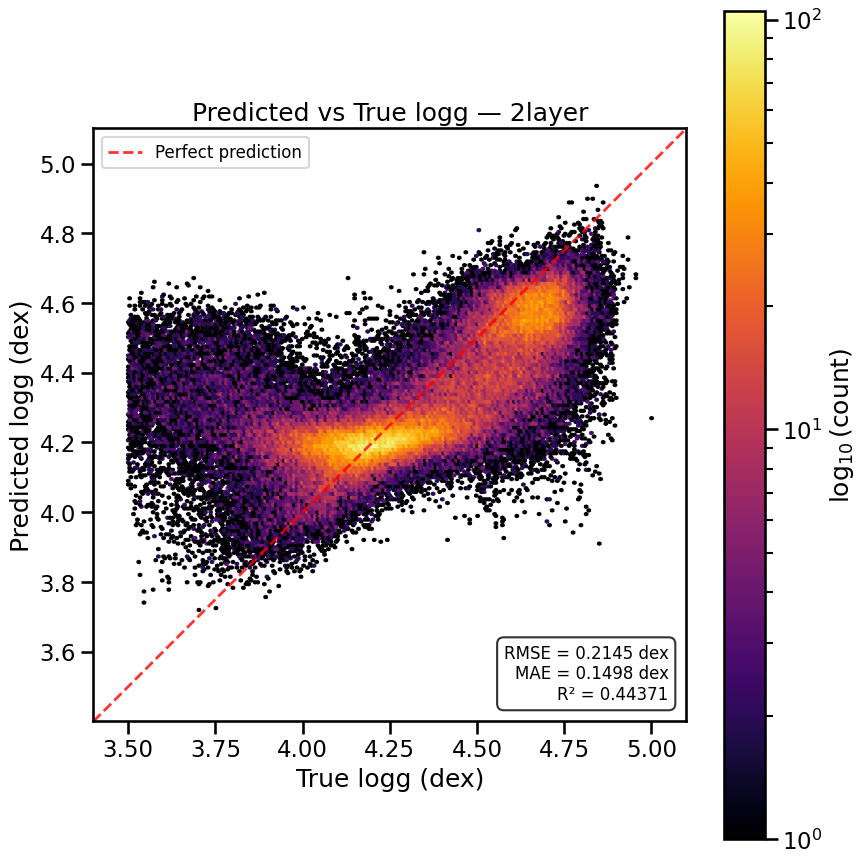

Saved: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\logg\2layer\one_to_one_plot.png


In [23]:
fig, ax = plt.subplots(figsize=(9, 9))

hb = ax.hexbin(y_true, y_pred, gridsize=200, cmap="inferno", mincnt=1, bins="log")
cb = plt.colorbar(hb, ax=ax, label=r"$\log_{10}$(count)")

lims = [min(y_true.min(), y_pred.min()) - 0.1,
        max(y_true.max(), y_pred.max()) + 0.1]
ax.plot(lims, lims, "r--", linewidth=2, alpha=0.8, label="Perfect prediction")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True logg (dex)")
ax.set_ylabel("Predicted logg (dex)")
ax.set_title(f"Predicted vs True logg â€” {VARIANT_NAME}")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=12)

textstr = f"RMSE = {rmse_dex:.4f} dex\nMAE = {mae_dex:.4f} dex\nRÂ² = {r2:.5f}"
ax.text(0.97, 0.03, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(VARIANT_RESULTS_DIR / "one_to_one_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {VARIANT_RESULTS_DIR / 'one_to_one_plot.png'}")

## 18. Residual Plot

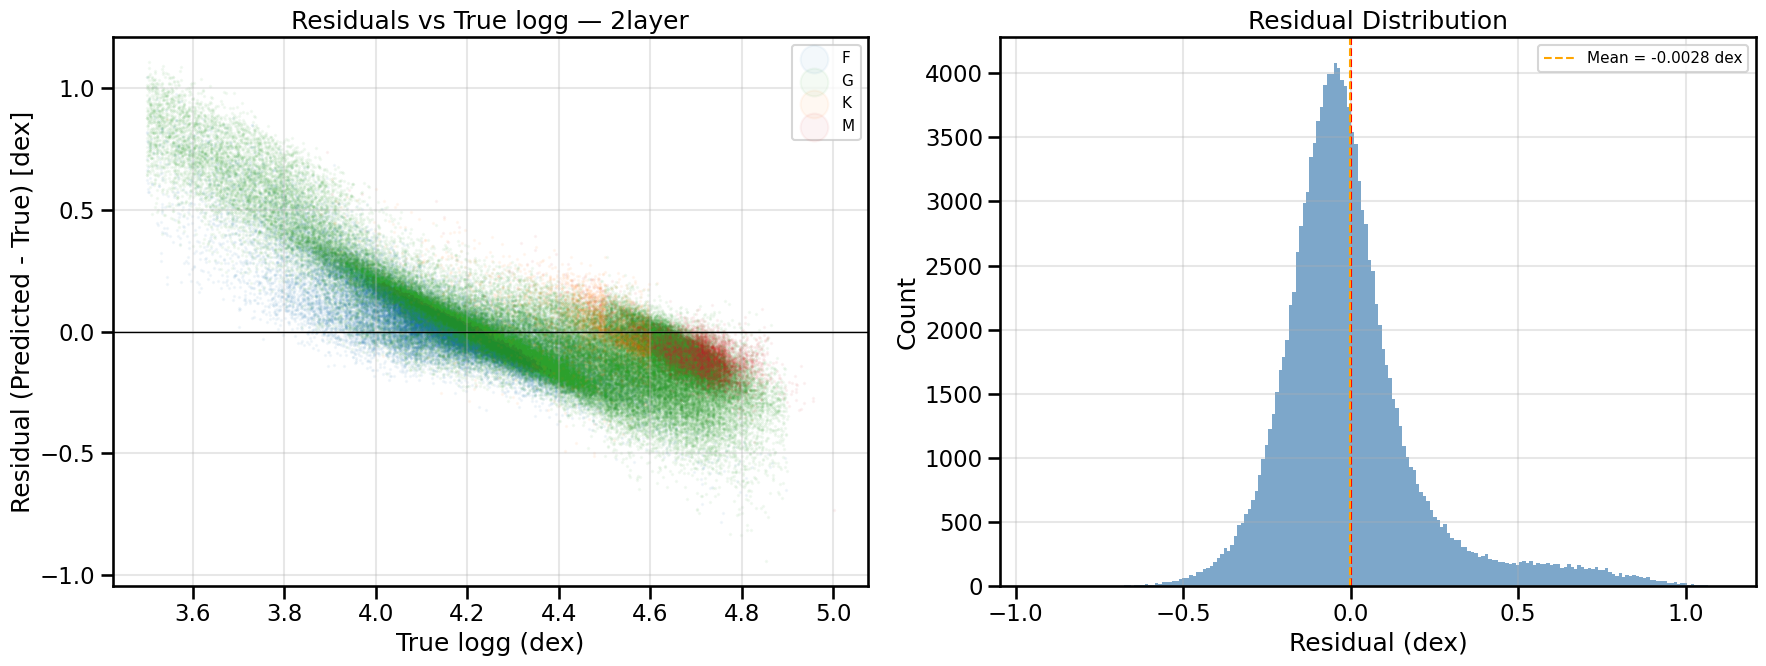

Saved: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\logg\2layer\residual_plot.png


In [24]:
residuals = y_pred - y_true

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
colors_map = {"F": "#1f77b4", "G": "#2ca02c", "K": "#ff7f0e", "M": "#d62728"}
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    ax.scatter(y_true[mask], residuals[mask], alpha=0.05, s=1,
               color=colors_map[stype], label=stype, rasterized=True)
ax.axhline(0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("True logg (dex)")
ax.set_ylabel("Residual (Predicted - True) [dex]")
ax.set_title(f"Residuals vs True logg â€” {VARIANT_NAME}")
ax.legend(markerscale=20, fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(residuals, bins=200, edgecolor="none", alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.axvline(np.mean(residuals), color="orange", linestyle="--", linewidth=1.5,
           label=f"Mean = {np.mean(residuals):.4f} dex")
ax.set_xlabel("Residual (dex)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VARIANT_RESULTS_DIR / "residual_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {VARIANT_RESULTS_DIR / 'residual_plot.png'}")

## 19. Save Artifacts

In [ ]:
# Model checkpoint
model_save_path = MODELS_DIR / "logg" / f"stellar_logg_ann_{VARIANT_NAME}_best.pth"
torch.save({
    "model_state_dict": best_model_state,
    "input_dim": len(FEATURE_COLS),
    "feature_cols": FEATURE_COLS,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "architecture": str(model),
    "variant": VARIANT_NAME,
}, model_save_path)
print(f"Model saved to {model_save_path}")

# Scaler
scaler_save_path = MODELS_DIR / "logg" / f"scaler_{VARIANT_NAME}.pkl"
joblib.dump(scaler, scaler_save_path)
print(f"Scaler saved to {scaler_save_path}")

# Metrics JSON
metrics = {
    "variant": VARIANT_NAME,
    "rmse_dex": round(float(rmse_dex), 6),
    "mae_dex": round(float(mae_dex), 6),
    "median_ae_dex": round(float(median_ae_dex), 6),
    "r2_score": round(float(r2), 6),
    "best_epoch": best_epoch,
    "total_epochs_run": len(train_losses),
    "n_train_augmented": len(y_train_aug),
    "n_train_original_trimmed": len(y_train_orig),
    "n_augmented_rows": n_augmented,
    "n_val": len(y_val),
    "n_test": len(y_test),
    "n_features": len(FEATURE_COLS),
    "per_type_r2": {k: round(v["r2"], 6) for k, v in per_type_metrics.items()},
    "per_type_rmse": {k: round(v["rmse"], 6) for k, v in per_type_metrics.items()},
}
metrics_path = VARIANT_RESULTS_DIR / "test_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to {metrics_path}")

print(f"\n{'=' * 50}")
print(f"  All artifacts saved — {VARIANT_NAME} variant")
print(f"{'=' * 50}")

## 20. Permutation Importance (on color features)

In [ ]:
def calculate_permutation_importance(model, loader, feature_names, device):
    model.eval()
    all_X = []
    all_y = []
    with torch.no_grad():
        for Xb, yb in loader:
            all_X.append(Xb)
            all_y.append(yb)

    X_all = torch.cat(all_X).to(device)
    y_all = torch.cat(all_y).cpu().numpy().flatten()

    with torch.no_grad():
        baseline_preds = model(X_all).cpu().numpy().flatten()
    baseline_mse = mean_squared_error(y_all, baseline_preds)
    print(f"Baseline Test MSE: {baseline_mse:.6f}")

    importances = []
    for i, feat in enumerate(feature_names):
        X_perm = X_all.clone()
        perm_idx = torch.randperm(X_perm.size(0))
        X_perm[:, i] = X_perm[perm_idx, i]
        with torch.no_grad():
            perm_preds = model(X_perm).cpu().numpy().flatten()
        perm_mse = mean_squared_error(y_all, perm_preds)
        importances.append({
            "Feature": feat,
            "Importance (MSE Increase)": perm_mse - baseline_mse,
            "Relative Importance": (perm_mse - baseline_mse) / baseline_mse,
        })
    return pd.DataFrame(importances).sort_values("Importance (MSE Increase)", ascending=False)

importance_df = calculate_permutation_importance(model, test_loader, FEATURE_COLS, DEVICE)

print(f"\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
top_df = importance_df.head(20)
sns.barplot(data=top_df, x="Importance (MSE Increase)", y="Feature", palette="viridis", ax=ax)
ax.set_title(f"Feature Importance — {VARIANT_NAME} (Top 20)")
ax.set_xlabel("Increase in MSE when feature is shuffled")
ax.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(VARIANT_RESULTS_DIR / "permutation_importance.png", dpi=200, bbox_inches="tight")
plt.show()

## 21. Comparison with Baseline

In [27]:
# Baseline metrics (from stellar_teff_ann_cpu_171_features.ipynb)
baseline = {
    "rmse_dex": 0.20586,
    "r2_score": 0.487838,
    "mae_dex": 0.141182,
    "per_type_r2": {"F": 0.1932, "G": 0.3872, "K": -0.5607, "M": 0.3545},
}

print("=" * 70)
print("  COMPARISON: Baseline (171 colors) vs This Model (PCA + teff)")
print("=" * 70)
print(f"\n  {'Metric':<20} {'Baseline':>12} {'This Model':>12} {'Change':>12}")
print(f"  {'-'*20} {'-'*12} {'-'*12} {'-'*12}")
print(f"  {'RMSE (dex)':<20} {baseline['rmse_dex']:>12.4f} {rmse_dex:>12.4f} {rmse_dex - baseline['rmse_dex']:>+12.4f}")
print(f"  {'MAE (dex)':<20} {baseline['mae_dex']:>12.4f} {mae_dex:>12.4f} {mae_dex - baseline['mae_dex']:>+12.4f}")
print(f"  {'RÂ²':<20} {baseline['r2_score']:>12.5f} {r2:>12.5f} {r2 - baseline['r2_score']:>+12.5f}")

print(f"\n  Per-Spectral-Type RÂ²:")
print(f"  {'Type':<6} {'Baseline':>10} {'This':>10} {'Change':>10}")
print(f"  {'----':<6} {'--------':>10} {'----':>10} {'------':>10}")
for stype in ["F", "G", "K", "M"]:
    bl = baseline["per_type_r2"].get(stype, float('nan'))
    curr = per_type_metrics.get(stype, {}).get("r2", float('nan'))
    print(f"  {stype:<6} {bl:>10.4f} {curr:>10.4f} {curr - bl:>+10.4f}")

target_met = r2 > 0.7
print(f"\n  RÂ² > 0.7 target: {'*** ACHIEVED ***' if target_met else 'NOT YET ACHIEVED'}")
print(f"  (Current RÂ² = {r2:.5f})")

  COMPARISON: Baseline (171 colors) vs This Model (PCA + teff)

  Metric                   Baseline   This Model       Change
  -------------------- ------------ ------------ ------------
  RMSE (dex)                 0.2059       0.2145      +0.0087
  MAE (dex)                  0.1412       0.1498      +0.0087
  RÂ²                        0.48784      0.44371     -0.04412

  Per-Spectral-Type RÂ²:
  Type     Baseline       This     Change
  ----     --------       ----     ------
  F          0.1932     0.1390    -0.0542
  G          0.3872     0.3349    -0.0523
  K         -0.5607    -0.1182    +0.4425
  M          0.3545    -1.0104    -1.3649

  RÂ² > 0.7 target: NOT YET ACHIEVED
  (Current RÂ² = 0.44371)
